### 1. Import Libraries

In [1]:
import tensorflow as tf # build/train model
from tensorflow.keras import layers, models # to create a nn layers and manage the  model
from tensorflow.keras.models import Sequential #  add one another layer
from tensorflow.keras.preprocessing import image # import  preprocessing utilities
import matplotlib.pyplot as plt  # for visualization
import numpy as np # works  with array  and mathematical operation
from PIL import Image # used for open  a  proprocessing image
import warnings # model
warnings.filterwarnings("ignore") # Handle missing values

### 2. Define Dataset Paths

In [2]:
train_path = "Dataset/Train"
validation_path = "Dataset/Validation"
test_path = "Dataset/Test"

### 3. Load Dataset

In [3]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(128, 128),
    batch_size=32
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    validation_path,
    image_size=(128, 128),
    batch_size=32
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(128, 128),
    batch_size=32
)

# line one= read  images from folder, convert image to batches
# third line= assign width and height for image
# batch size = how many images are sennt to  the model at the time

Found 28 files belonging to 28 classes.
Found 28 files belonging to 28 classes.
Found 28 files belonging to 28 classes.


### 4. Get Class Names

In [4]:
num_class_train_int =train_dataset.class_names

In [5]:
num_class_train = len(train_dataset.class_names)
print(train_dataset.class_names)
print("Class Names:", num_class_train)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NOTHING', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Class Names: 28


In [6]:
num_class_test = len(test_dataset.class_names)
print(test_dataset.class_names)
print("Class Names:", num_class_test)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NOTHING', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Class Names: 28


In [7]:
num_class_validation = len(validation_dataset.class_names)
print(validation_dataset.class_names)
print("Class Names:", num_class_validation)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NOTHING', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Class Names: 28


### 5. Visualize Sample Images

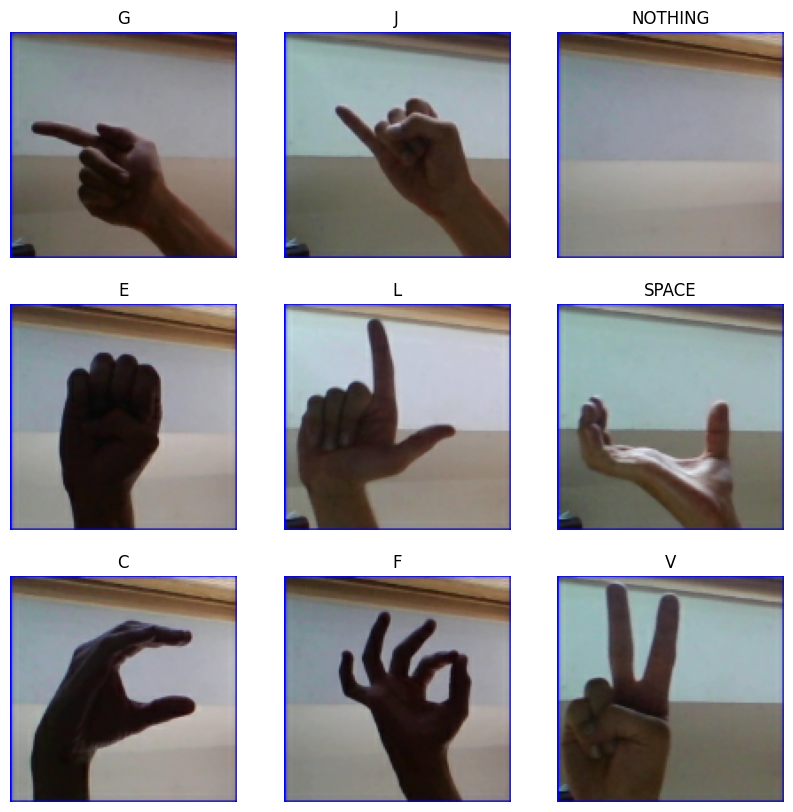

In [26]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(num_class_train_int[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
for image, large in train_dataset.take(1):
    print(image.shape)

(28, 128, 128, 3)


### 7. Build CNN Model

In [10]:
model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(128,128,3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_class_train, activation='softmax')
])

### 8. View Model Summary

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 28)                  │           3,612 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,308,252 (12.62 MB)

 Trainable params: 3,308,252 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

### 9. Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 10. Train Model

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0357 - loss: 3.3340 - val_accuracy: 0.0714 - val_loss: 3.3649
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.0714 - loss: 3.3649 - val_accuracy: 0.2500 - val_loss: 3.1821
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.2500 - loss: 3.1821 - val_accuracy: 0.3571 - val_loss: 3.0707
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.3571 - loss: 3.0707 - val_accuracy: 0.5357 - val_loss: 2.8705
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.5357 - loss: 2.8705 - val_accuracy: 0.6429 - val_loss: 2.5496
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6429 - loss: 2.5496 - val_accuracy: 0.7143 - val_loss: 2.0905
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7143 - loss: 2.0905 - val_accuracy: 0.8929 - val_loss: 1.5395
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8929 - loss: 1.5395 - val_accuracy: 0.7500 - val_loss: 1.

### 11. Evaluate Model

In [14]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy :", test_accuracy)
print("Test Loss     :", test_loss)   

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.2016
Test Accuracy : 1.0
Test Loss     : 0.20155498385429382


### 12. Plot Accuracy Graph

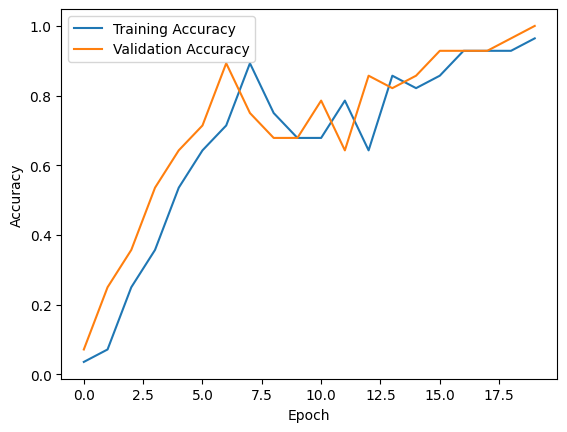

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 13. Save Model

In [16]:
model.save("animal_classifier_model.h5")
# save dl trained deep learnning model
# .h5 = HDF5 format ( older but still supported)

### 14. Load Saved Model

In [17]:
model = tf.keras.models.load_model("animal_classifier_model.h5")
# load previously saved trained model into memory

### 15. Prediction Function with Confidence Score

In [18]:
def predict_sign(img_path):

    img = tf.keras.utils.load_img(
        img_path,
        target_size=(128,128)  # resize 128*128
    )

    plt.imshow(img) # display the loaded image
    plt.axis("off") # remove axis values around the image
    plt.show() # display the image

    img_array = tf.keras.utils.img_to_array(img) # convert image into  nnumerical array format

    img_array = np.expand_dims(img_array, axis=0) # add batch dimensions

    prediction = model.predict(img_array) # send the image into trained model

    class_index = np.argmax(prediction) # findingthe highest  probaility index

    class_name = train_dataset.class_names[class_index] # convert numeric index into class label

    print("Predicted Sign:", class_name) # print final predicted letter

### 16. Test Prediction

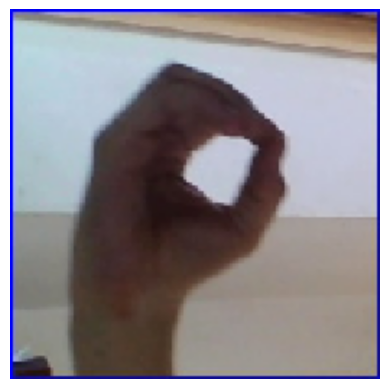

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Sign: O


In [27]:
predict_sign('o_test.jpg')

# Project Workflow Summary

```text
Dataset Creation
        ↓
Folder Structuring
        ↓
Load Dataset
        ↓
Preprocessing
        ↓
CNN Model Building
        ↓
Training
        ↓
Validation
        ↓
Testing
        ↓
Save Model
        ↓
Predict New Images
```

# THANK YOU